In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=GTrESYrG01F5gGw5JKbfxGMmShGPN5&access_type=offline&code_challenge=SrtVNAXfi7mUmkiuIVqiv6WfRepRLX_tfQq-79G0U0g&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


Updates are available for some Google Clo

In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/05 21:03:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

sl_eff=session.spark.read.parquet("gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect")

l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet")

# Pleiotropy on TAs estimation consistency

In [4]:
qd_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets").select("studyLocusId").cache()
qd_cs.count()

70618

In [5]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet")

In [6]:
l2g_full_diseases=l2g_full.join(qd_cs,"studyLocusId","inner").cache()
l2g_full_diseases.count()

70400

In [7]:
gwas_ta=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/gwas_therapeutic_areas")
gwas_ta.count()

100526

In [8]:
gwas_ta.show(1)

25/10/05 21:21:33 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+------+-----------+---------+--------------------+------------------------+---------------------+--------+----------------+----------------------+---------------+------------------+----------------------------------+--------------------+------+---------+--------+---------+---------------------+-------------------+------------------+---------------+-------------+--------------------+-----------+---------+---------------+-------------+--------------------+-----------+----------------------+-----------+---------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+-------

In [9]:
#gwas_ta.columns

In [10]:
gwas_ta=gwas_ta.select(
    "studyId",
    "mappedTherapeuticAreas"
).distinct()
gwas_ta.count()

100526

In [11]:
l2g_full_diseases=l2g_full_diseases.join(gwas_ta,"studyId","inner").cache()
l2g_full_diseases.count()

70400

In [12]:
l2g_full_diseases.show(1)

+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+----------------------+
|             studyId|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|mappedTherapeuticAreas|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+----------------------+
|FINNGEN_R12_CD2_B...|1d7173e340d92962f...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1|0.10647321428571428|16_17260032_AT_A|2024|     0|[EFO_0009675]|         0|             1|   0|       [MONDO_0045024]|
+--------------------+--------------------+---------------+-----

In [13]:
genes_therapeutic_areas = (
    l2g_full_diseases.groupBy("geneId")
    .agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias(
            "uniqueDiseases"
        ),
        f.size(
            f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))
        ).alias("uniqueTherapeuticAreas")
    )
)

In [14]:
genes_therapeutic_areas.count()

8285

In [15]:
genes_therapeutic_areas.filter((f.col("uniqueDiseases")>=10) & (f.col("uniqueTherapeuticAreas")==2)).show()

+---------------+--------------+----------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|
+---------------+--------------+----------------------+
|ENSG00000139618|            18|                     2|
|ENSG00000149311|            11|                     2|
|ENSG00000159197|            15|                     2|
|ENSG00000162267|            10|                     2|
|ENSG00000166323|            12|                     2|
|ENSG00000178202|            12|                     2|
|ENSG00000107798|            12|                     2|
|ENSG00000128591|            11|                     2|
|ENSG00000168779|            10|                     2|
|ENSG00000174371|            13|                     2|
|ENSG00000214290|            15|                     2|
+---------------+--------------+----------------------+



In [16]:
genes_therapeutic_areas.show(1)

+---------------+--------------+----------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|
+---------------+--------------+----------------------+
|ENSG00000000003|             2|                     2|
+---------------+--------------+----------------------+
only showing top 1 row



In [17]:
pleiotropy_score_2025 = (
    l2g_full_diseases.groupBy("geneId")
    .agg(
        f.size(
            f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))
        ).alias("uniqueTherapeuticAreas")
    )
    .withColumnRenamed("geneId","targetId")
)
pleiotropy_score_2025.count()

8285

In [18]:
pleiotropy_score_2025.show(1)

+---------------+----------------------+
|       targetId|uniqueTherapeuticAreas|
+---------------+----------------------+
|ENSG00000000003|                     2|
+---------------+----------------------+
only showing top 1 row



In [29]:
import pandas as pd
correlation_results = pd.DataFrame({
    'year': [2025],  # assuming 'year' variable is available from your loop
    'correlation': [1]
})
correlation_results

,year,correlation
0,2025,1


In [30]:
for year in range(2024,2009,-1):
    print(year)

    pleiotropy_score_new = (
        l2g_full_diseases.filter(f.col("year")<=year).groupBy("geneId")
        .agg(
            f.size(
                f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))
            ).alias("uniqueTherapeuticAreas")
        )
        .withColumnRenamed("geneId","targetId")
    )
    joined_pleiotropy = (
        pleiotropy_score_new
        .join(
            pleiotropy_score_2025.withColumnRenamed("uniqueTherapeuticAreas", "uniqueTherapeuticAreas_priv"),
            on="targetId", 
            how="inner"
        )
    )
    # Convert to pandas and calculate Spearman correlation
    joined_pleiotropy_pd = joined_pleiotropy.toPandas()
    correlation = joined_pleiotropy_pd['uniqueTherapeuticAreas'].corr(
        joined_pleiotropy_pd['uniqueTherapeuticAreas_priv'], 
        method='pearson'
    )
    correlation_results = pd.concat([correlation_results, 
                                    pd.DataFrame({'year': [year], 'correlation': [correlation]})], 
                                   ignore_index=True)
    #pleiotropy_score_priv = pleiotropy_score_new.cache()


2024
2023


2022
2021
2020
2019
2018
2017
2016
2015
2014
2013
2012
2011
2010


In [31]:
correlation_results

,year,correlation
0,2025,1.000000
1,2024,0.993642
2,2023,0.858384
3,2022,0.824125
4,2021,0.783570
5,2020,0.717974
6,2019,0.674888
7,2018,0.633310
8,2017,0.555312
9,2016,0.530569


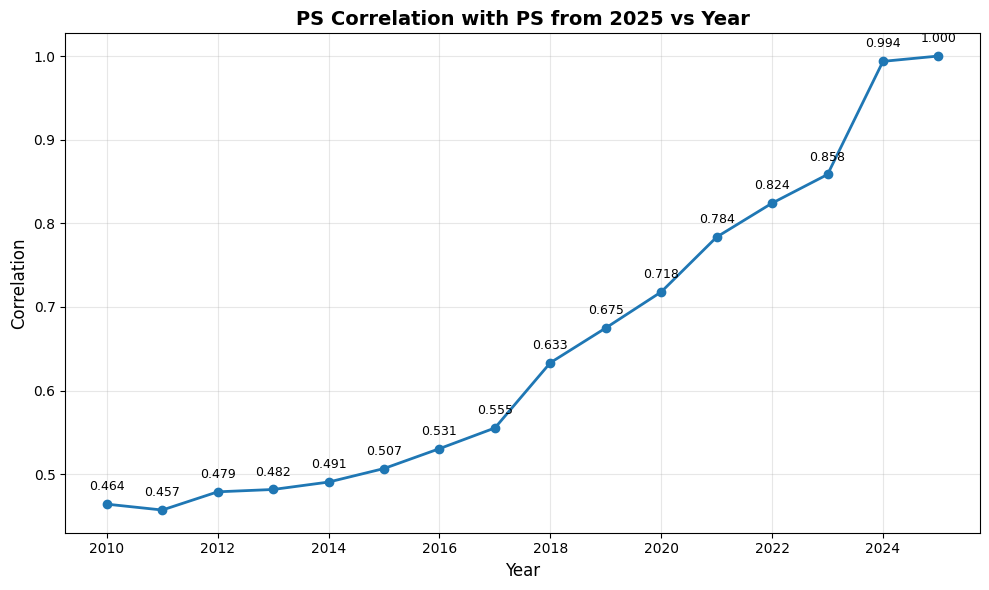

In [33]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(correlation_results['year'], correlation_results['correlation'], 
         marker='o', linewidth=2, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('PS Correlation with PS from 2025 vs Year', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Optional: Set y-axis limits if needed
# plt.ylim(0, 1)  # Uncomment if you want to set specific y-axis range

# Optional: Add correlation values as text labels on points
for i, row in correlation_results.iterrows():
    plt.annotate(f'{row["correlation"]:.3f}', 
                (row['year'], row['correlation']),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [34]:
correlation_results_ta=correlation_results

In [36]:
pleiotropy_score_2025_ta=pleiotropy_score_2025.cache()
pleiotropy_score_2025_ta.count()

8285

# Pleiotropy estimation measurments and diseases

In [37]:
qd_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_credible_sets").select("studyLocusId").cache()
qd_cs.count()

25/10/05 21:32:35 WARN CacheManager: Asked to cache already cached data.


70618

In [38]:
qm_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets").select("studyLocusId").cache()
qm_cs.count()

450357

In [39]:
qmd=qd_cs.union(qm_cs).cache()
qmd.count()

520975

In [40]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet")

In [41]:
l2g_full_diseases=l2g_full.join(qd_cs,"studyLocusId","inner").cache()
l2g_full_diseases.count()

25/10/05 21:32:48 WARN CacheManager: Asked to cache already cached data.


70400

In [42]:
l2g_full_diseases.show(1)

+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|        studyLocusId|             studyId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|1d7173e340d92962f...|FINNGEN_R12_CD2_B...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1|0.10647321428571428|16_17260032_AT_A|2024|     0|[EFO_0009675]|         0|             1|   0|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+---

In [43]:
l2g_full_measurements=l2g_full.join(qm_cs,"studyLocusId","inner").cache()
l2g_full_measurements.count()

453009

In [44]:
l2g_full_qmd=l2g_full.join(qmd,"studyLocusId","inner").cache()
l2g_full_qmd.count()

523409

In [47]:
l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases.filter(f.col("year")<=2025).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)
pleiotropy_score_2025 = l2g_evidence.groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_score_2025.count()

8285

In [48]:
pleiotropy_score_2025.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000168314|                   4|
+---------------+--------------------+
only showing top 1 row



In [50]:
import pandas as pd
correlation_results = pd.DataFrame({
    'year': [2025],  # assuming 'year' variable is available from your loop
    'correlation': [1]
})
correlation_results

,year,correlation
0,2025,1


In [51]:
for year in range(2024,2009,-1):
    print(year)
    l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases.filter(f.col("year")<=year).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
    )
    pleiotropy_score_new = l2g_evidence.groupBy("targetId").agg(
        f.countDistinct("diseaseId").alias("unique_disease_count")
    )
    joined_pleiotropy = (
        pleiotropy_score_new
        .join(
            pleiotropy_score_2025.withColumnRenamed("unique_disease_count", "unique_disease_count_priv"),
            on="targetId", 
            how="inner"
        )
    )
    # Convert to pandas and calculate Spearman correlation
    joined_pleiotropy_pd = joined_pleiotropy.toPandas()
    correlation = joined_pleiotropy_pd['unique_disease_count'].corr(
        joined_pleiotropy_pd['unique_disease_count_priv'], 
        method='pearson'
    )
    correlation_results = pd.concat([correlation_results, 
                                    pd.DataFrame({'year': [year], 'correlation': [correlation]})], 
                                   ignore_index=True)
    #pleiotropy_score_priv = pleiotropy_score_new.cache()


2024


2023


2022


2021


2020


2019


2018


2017


2016


2015


2014


2013


2012


2011


2010


In [52]:
correlation_results

,year,correlation
0,2025,1.000000
1,2024,0.997302
2,2023,0.904980
3,2022,0.889621
4,2021,0.866263
5,2020,0.817623
6,2019,0.778383
7,2018,0.760816
8,2017,0.615891
9,2016,0.572884


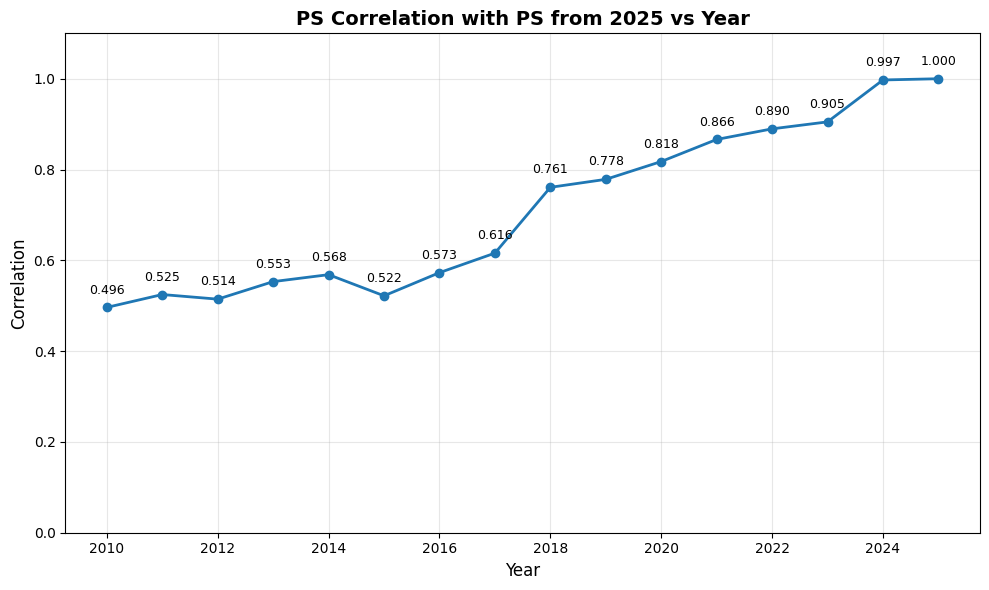

In [53]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(correlation_results['year'], correlation_results['correlation'], 
         marker='o', linewidth=2, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('PS Correlation with PS from 2025 vs Year', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

# Optional: Set y-axis limits if needed
# plt.ylim(0, 1)  # Uncomment if you want to set specific y-axis range

# Optional: Add correlation values as text labels on points
for i, row in correlation_results.iterrows():
    plt.annotate(f'{row["correlation"]:.3f}', 
                (row['year'], row['correlation']),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [55]:
correlation_results_disease=correlation_results
pleiotropy_score_2025_dis=pleiotropy_score_2025.cache()
pleiotropy_score_2025_dis.count()

25/10/05 21:40:25 WARN CacheManager: Asked to cache already cached data.


8285

# Measurement pleiotropy score

In [57]:
l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_measurements.filter(f.col("year")<=2025).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)
pleiotropy_score_2025 = l2g_evidence.groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_score_2025.count()

15160

In [59]:
import pandas as pd
correlation_results = pd.DataFrame({
    'year': [2025],  # assuming 'year' variable is available from your loop
    'correlation': [1]
})
correlation_results

,year,correlation
0,2025,1


In [60]:
for year in range(2024,2009,-1):
    print(year)
    l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_measurements.filter(f.col("year")<=year).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
    )
    pleiotropy_score_new = l2g_evidence.groupBy("targetId").agg(
        f.countDistinct("diseaseId").alias("unique_disease_count")
    )
    joined_pleiotropy = (
        pleiotropy_score_new
        .join(
            pleiotropy_score_2025.withColumnRenamed("unique_disease_count", "unique_disease_count_priv"),
            on="targetId", 
            how="inner"
        )
    )
    # Convert to pandas and calculate Spearman correlation
    joined_pleiotropy_pd = joined_pleiotropy.toPandas()
    correlation = joined_pleiotropy_pd['unique_disease_count'].corr(
        joined_pleiotropy_pd['unique_disease_count_priv'], 
        method='pearson'
    )
    correlation_results = pd.concat([correlation_results, 
                                    pd.DataFrame({'year': [year], 'correlation': [correlation]})], 
                                   ignore_index=True)
    #pleiotropy_score_priv = pleiotropy_score_new.cache()


2024


2023


2022


2021


2020


2019


2018


2017


2016


2015


2014


2013


2012


2011


2010


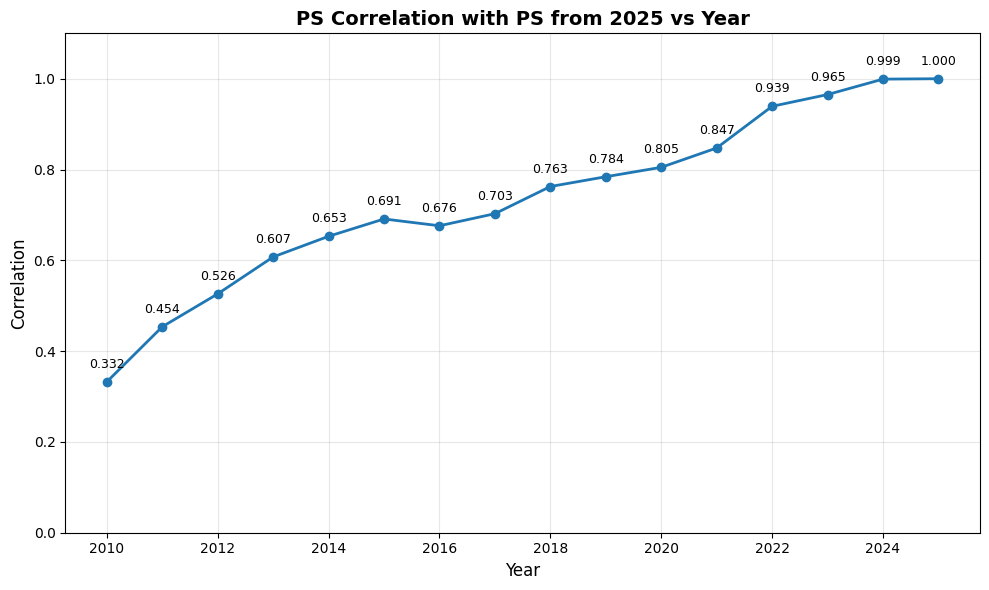

In [62]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(correlation_results['year'], correlation_results['correlation'], 
         marker='o', linewidth=2, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('PS Correlation with PS from 2025 vs Year', fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

# Optional: Set y-axis limits if needed
# plt.ylim(0, 1)  # Uncomment if you want to set specific y-axis range

# Optional: Add correlation values as text labels on points
for i, row in correlation_results.iterrows():
    plt.annotate(f'{row["correlation"]:.3f}', 
                (row['year'], row['correlation']),
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [63]:
correlation_results_measure=correlation_results
pleiotropy_score_2025_measure=pleiotropy_score_2025.cache()
pleiotropy_score_2025_measure.count()

25/10/05 21:45:46 WARN CacheManager: Asked to cache already cached data.


15160

# Heatmap of correshion

In [64]:
# First, join all three datasets by targetId
correlation_data = (
    pleiotropy_score_2025_measure
    .withColumnRenamed("unique_disease_count", "measure_count")
    .join(
        pleiotropy_score_2025_ta.withColumnRenamed("uniqueTherapeuticAreas", "ta_count"),
        on="targetId",
        how="inner"
    )
    .join(
        pleiotropy_score_2025_dis.withColumnRenamed("unique_disease_count", "disease_count"),
        on="targetId", 
        how="inner"
    )
)

# Check the joined data
correlation_data.show(5)
print(f"Number of targets with all three scores: {correlation_data.count()}")

+---------------+-------------+--------+-------------+
|       targetId|measure_count|ta_count|disease_count|
+---------------+-------------+--------+-------------+
|ENSG00000115252|           28|       2|            3|
|ENSG00000120341|           42|       3|            8|
|ENSG00000115705|            5|       3|            7|
|ENSG00000153885|            9|       1|            1|
|ENSG00000143013|           36|       5|           10|
+---------------+-------------+--------+-------------+
only showing top 5 rows

Number of targets with all three scores: 7804


In [103]:
# First, join all three datasets by targetId
correlation_data = (
    pleiotropy_score_2025_ta
    .withColumnRenamed("unique_disease_count", "ta_count")
    .join(
        pleiotropy_score_2025_dis.withColumnRenamed("unique_disease_count", "disease_count"),
        on="targetId", 
        how="inner"
    )
)

# Check the joined data
correlation_data.show(5)
print(f"Number of targets with all three scores: {correlation_data.count()}")

+---------------+----------------------+-------------+
|       targetId|uniqueTherapeuticAreas|disease_count|
+---------------+----------------------+-------------+
|ENSG00000168314|                     3|            4|
|ENSG00000172765|                     2|            2|
|ENSG00000163406|                     3|            7|
|ENSG00000145723|                     5|            7|
|ENSG00000214194|                     1|            1|
+---------------+----------------------+-------------+
only showing top 5 rows

Number of targets with all three scores: 8285


In [108]:
correlation_data.filter((f.col("disease_count")>=10)&(f.col("uniqueTherapeuticAreas")<=1)).show()

+---------------+----------------------+-------------+
|       targetId|uniqueTherapeuticAreas|disease_count|
+---------------+----------------------+-------------+
|ENSG00000132383|                     1|           14|
|ENSG00000147679|                     1|           16|
+---------------+----------------------+-------------+



In [65]:
# Convert to pandas for correlation matrix calculation
correlation_df = correlation_data.select("measure_count", "ta_count", "disease_count").toPandas()

# Calculate correlation matrix
import pandas as pd
import numpy as np

correlation_matrix = correlation_df.corr(method='pearson')
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
               measure_count  ta_count  disease_count
measure_count       1.000000  0.513946       0.518726
ta_count            0.513946  1.000000       0.844069
disease_count       0.518726  0.844069       1.000000


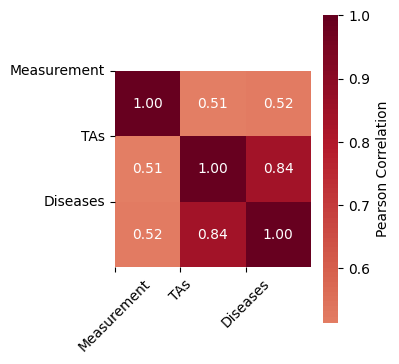

In [77]:
# Create a beautiful heatmap of the correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values
            cmap='RdBu_r',  # Color scheme (red-blue)
            center=0,  # Center colormap at 0
            square=True,  # Make cells square
            fmt='.2f',  # Format to 3 decimal places
            cbar_kws={'label': 'Pearson Correlation'})

# Customize labels
#plt.title('Correlation Matrix: Pleiotropy Scores', fontsize=14, fontweight='bold', pad=20)
#plt.xlabel('Pleiotropy Measures', fontsize=12)
#plt.ylabel('Pleiotropy Measures', fontsize=12)

# Rename tick labels for better readability
tick_labels = ['Measurement', 'TAs', 'Diseases']
plt.xticks(range(len(tick_labels)), tick_labels, rotation=45)
plt.yticks(range(len(tick_labels)), tick_labels, rotation=0)

plt.tight_layout()
plt.show()

# Plot of consistency across years

In [85]:
l2g_evidence=chemblDrugEnrichment.to_disease_target_evidence(table_with_score=l2g_full_diseases.filter(f.col("year")<=2025).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g_combined",
    study_locus=sl,
    study_index=si,
    min_score=0.1
)

In [86]:
l2g_evidence.show(1)

+----------+------------+---------------+-----------+------------------+--------------------+
|datatypeId|datasourceId|       targetId|  diseaseId|     resourceScore|        studyLocusId|
+----------+------------+---------------+-----------+------------------+--------------------+
|      GWAS|l2g_combined|ENSG00000108551|EFO_0004698|0.7999526262283325|0590e724aa69711f7...|
+----------+------------+---------------+-----------+------------------+--------------------+
only showing top 1 row



In [96]:
# First, get the year information by joining back to the original data
l2g_evidence_with_year = (
    l2g_evidence
    .join(
        l2g_full_diseases.select("studyLocusId", "year").distinct(),
        on="studyLocusId",
        how="inner"
    )
)

# Calculate cumulative unique diseaseIds for each year from 2010-2024
cumulative_disease_counts = []

for year in range(2010, 2026):  # 2010 to 2024 inclusive
    print(f"Processing year: {year}")
    
    # Filter data up to and including the current year
    data_up_to_year = l2g_evidence_with_year.filter(f.col("year") <= year)
    
    # Count unique diseaseIds
    unique_diseases = data_up_to_year.select("diseaseId").distinct().count()
    
    cumulative_disease_counts.append({
        'year': year,
        'cumulative_unique_diseases': unique_diseases
    })

# Convert to pandas DataFrame for easy viewing and plotting
import pandas as pd
cumulative_df = pd.DataFrame(cumulative_disease_counts)
print("\nCumulative unique disease counts by year:")
print(cumulative_df)

Processing year: 2010


Processing year: 2011


Processing year: 2012


Processing year: 2013


Processing year: 2014


Processing year: 2015


Processing year: 2016


Processing year: 2017


Processing year: 2018


Processing year: 2019


Processing year: 2020


Processing year: 2021


Processing year: 2022


Processing year: 2023


Processing year: 2024


Processing year: 2025



Cumulative unique disease counts by year:
    year  cumulative_unique_diseases
0   2010                          79
1   2011                         105
2   2012                         127
3   2013                         154
4   2014                         173
5   2015                         206
6   2016                         238
7   2017                         262
8   2018                         444
9   2019                         494
10  2020                         526
11  2021                         657
12  2022                         696
13  2023                         737
14  2024                        1391
15  2025                        1394


In [88]:
cumulative_df

,year,cumulative_unique_diseases
0,2010,79
1,2011,105
2,2012,127
3,2013,154
4,2014,173
5,2015,206
6,2016,238
7,2017,262
8,2018,444
9,2019,494


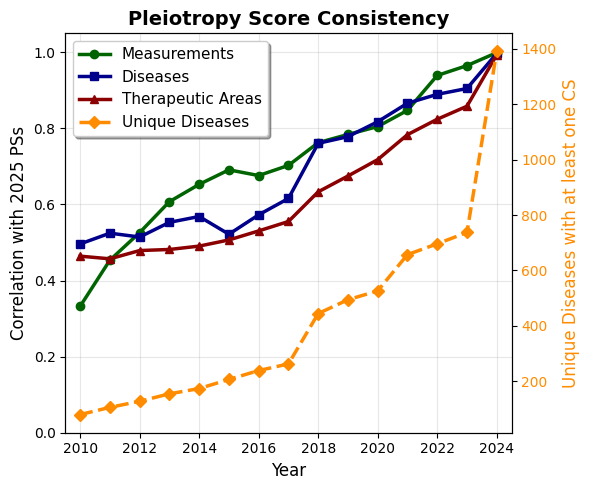

In [95]:
import matplotlib.pyplot as plt

correlation_results_measure=correlation_results_measure[correlation_results_measure["year"]<=2024]
correlation_results_disease=correlation_results_disease[correlation_results_disease["year"]<=2024]
correlation_results_ta=correlation_results_ta[correlation_results_ta["year"]<=2024]

# Create the combined plot with dual y-axes
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot correlation lines on left y-axis
ax1.plot(correlation_results_measure['year'], correlation_results_measure['correlation'], 
         marker='o', linewidth=2.5, markersize=6, label='Measurements', color='darkgreen')

ax1.plot(correlation_results_disease['year'], correlation_results_disease['correlation'], 
         marker='s', linewidth=2.5, markersize=6, label='Diseases', color='darkblue')

ax1.plot(correlation_results_ta['year'], correlation_results_ta['correlation'], 
         marker='^', linewidth=2.5, markersize=6, label='Therapeutic Areas', color='darkred')

# Left y-axis styling
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Correlation with 2025 PSs', fontsize=12, color='black')
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2009.5, 2024.5)

# Create second y-axis for cumulative diseases
ax2 = ax1.twinx()
ax2.plot(cumulative_df['year'], cumulative_df['cumulative_unique_diseases'], 
         marker='D', linewidth=2.5, markersize=6, label='Unique Diseases', 
         color='darkorange', linestyle='--')

# Right y-axis styling
ax2.set_ylabel('Unique Diseases with at least one CS', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, frameon=True, fancybox=True, shadow=True, loc='upper left')

plt.title('Pleiotropy Score Consistency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Combined evidnece

In [4]:
combined_evidence = session.spark.read.csv("./data/combined_evidence_with_measurements.csv", header=True, inferSchema=True)

In [5]:
combined_evidence.groupBy("source").count().show()

+-----------------+------+
|           source| count|
+-----------------+------+
|     all_diseases| 36858|
|      gene_burden|  6857|
|             omim|  6596|
|         orphanet|  6192|
| all_measurements|150360|
|           ChEMBL| 25234|
|    cancer_ChEMBL|  8811|
|        gwas_eQTL| 12343|
|    gwas_with_pav|  5441|
|           molQTL| 17755|
|non_cancer_ChEMBL| 16423|
+-----------------+------+



In [6]:
combined_evidence.select("targetId").distinct().count()

18809

In [7]:
pleiotropy_diseases = combined_evidence.filter(f.col("source")=="all_diseases").groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_diseases.count()

8285

In [8]:
pleiotropy_measurements = combined_evidence.filter(f.col("source")=="all_measurements").groupBy("targetId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
).cache()
pleiotropy_measurements.count()

15160

In [9]:
pleiotropy_measurements.show(1)

+---------------+--------------------+
|       targetId|unique_disease_count|
+---------------+--------------------+
|ENSG00000224578|                  39|
+---------------+--------------------+
only showing top 1 row



In [10]:
# Combine pleiotropy_measurements and pleiotropy_diseases
combined_pleiotropy = (
    pleiotropy_diseases
    .join(
        pleiotropy_measurements.withColumnRenamed(
            "unique_disease_count", "unique_measurement_count"
        ),
        on="targetId",
        how="full_outer"
    )
    .fillna(0, subset=["unique_disease_count", "unique_measurement_count"])
)

combined_pleiotropy.count()

15641

In [11]:
combined_pleiotropy.show(1)

+---------------+--------------------+------------------------+
|       targetId|unique_disease_count|unique_measurement_count|
+---------------+--------------------+------------------------+
|ENSG00000059588|                   1|                       7|
+---------------+--------------------+------------------------+
only showing top 1 row



In [12]:
# Pearson correlation using Spark
correlation = combined_pleiotropy.stat.corr("unique_disease_count", "unique_measurement_count")
print(f"Pearson correlation: {correlation}")

Pearson correlation: 0.5620166838332963


In [16]:
# Pearson correlation using Spark
correlation = combined_pleiotropy.filter(f.col("unique_disease_count")>0).stat.corr("unique_disease_count", "unique_measurement_count")
print(f"Pearson correlation: {correlation}")

Pearson correlation: 0.525035656208021


In [ ]:
# Pearson correlation using Spark
correlation = combined_pleiotropy.filter(f.col("unique_disease_count")>0).stat.corr("unique_disease_count", "unique_measurement_count")
print(f"Pearson correlation: {correlation}")

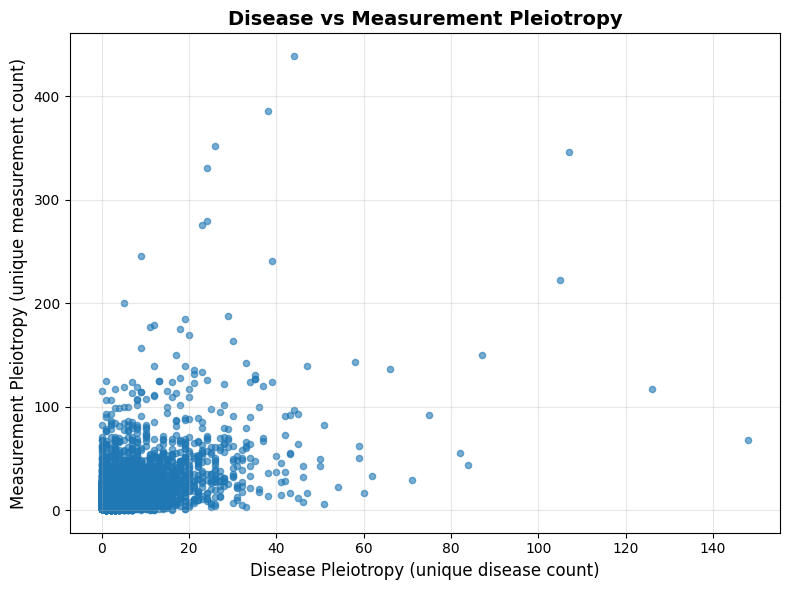

In [17]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to pandas
combined_pleiotropy_pd = combined_pleiotropy.toPandas()

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(combined_pleiotropy_pd['unique_disease_count'], 
            combined_pleiotropy_pd['unique_measurement_count'], 
            alpha=0.6, s=20)

plt.xlabel('Disease Pleiotropy (unique disease count)', fontsize=12)
plt.ylabel('Measurement Pleiotropy (unique measurement count)', fontsize=12)
plt.title('Disease vs Measurement Pleiotropy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

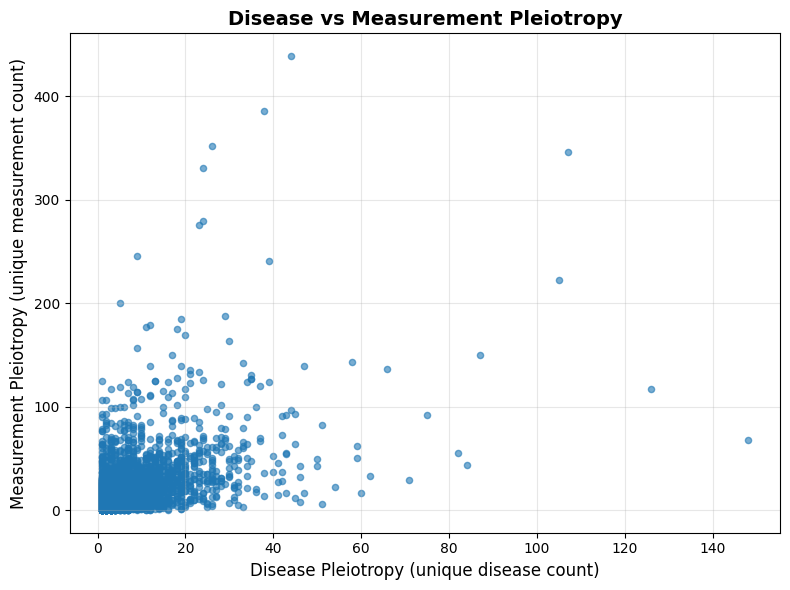

25/09/22 14:03:30 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 612239 ms exceeds timeout 120000 ms
25/09/22 14:03:30 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/22 14:03:30 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [18]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to pandas
combined_pleiotropy_pd = combined_pleiotropy.filter(f.col("unique_disease_count")>0).toPandas()

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(combined_pleiotropy_pd['unique_disease_count'], 
            combined_pleiotropy_pd['unique_measurement_count'], 
            alpha=0.6, s=20)

plt.xlabel('Disease Pleiotropy (unique disease count)', fontsize=12)
plt.ylabel('Measurement Pleiotropy (unique measurement count)', fontsize=12)
plt.title('Disease vs Measurement Pleiotropy', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()